In [2388]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from scripts import model_evaluation as model_eval

In [2389]:
X_train = pd.read_parquet('X_train_cleaned.parquet')
X_test = pd.read_parquet('X_test_cleaned.parquet')

y_train = pd.read_parquet('y_train.parquet')
y_test = pd.read_parquet('y_test.parquet')

In [2390]:
X_train.info()  

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

In [2391]:
X_train.shape

(5634, 19)

In [2392]:
cat_cols = ['PhoneService', 'MultipleLines', 'PaymentMethod',  
            'StreamingTV', 'OnlineSecurity', 'TechSupport',   
            'StreamingMovies', 'Contract', 'PaperlessBilling']

drop_cols = ['gender', 'Partner', 'Dependents',  'OnlineBackup', 'DeviceProtection', 'InternetService', 'TotalCharges']
    

In [2393]:
def restore_category_dtype(X):
    return pd.DataFrame(X).astype("category")

In [2394]:
cat_pipeline = Pipeline([
        ('ordinal_encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-2))
])

cat_feature_indices = list(range(len(cat_cols)))

In [2395]:
preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols)
], remainder='passthrough')

In [2396]:
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.cols)

In [2397]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.tenure_max_ = None

    def fit(self, X, y=None):
        self.tenure_max_ = X['tenure'].max()
        self.monthly_charge_mean_ = X['MonthlyCharges'].mean()
        return self

    def transform(self, X):
        X = X.copy()

        service_usage_score = (
            (X[['StreamingTV','StreamingMovies','OnlineBackup',
                'DeviceProtection','TechSupport','OnlineSecurity', 
                'PhoneService']] == 'Yes').sum(axis=1)
        )

        service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                        'TechSupport', 'StreamingTV', 'StreamingMovies']
        service_adoption_rate = (X[service_cols] == 'Yes').sum(axis=1) / len(service_cols)

        X['service_usage_ratio'] = service_usage_score / (X['tenure'] + 1)

        X['charge_per_service'] = X['MonthlyCharges'] / (service_usage_score + 1)

        X['high_cost_short_tenure'] = X['MonthlyCharges'] * (X['tenure'] < 12)

        X['loyalty_index'] = (
            X['tenure'] *
            X['Contract'].map({'Month-to-month': 0.5, 'One year': 1.5, 'Two year': 3.0}) *
            (1 + service_adoption_rate)
        )

        X['longterm_customers'] = (
            (X['Contract'] != 'Month-to-month').astype(int) +
            (X['Dependents'] == 'Yes').astype(int) +
            (X['tenure'] >= 5).astype(int) +
            (X['tenure'] >= 24).astype(int) +
            (X['PaperlessBilling'] == 'No').astype(int)
        )

        X['risk_score'] = (
            (X['PaymentMethod'] == 'Electronic check').astype(int) +
            (X['PaperlessBilling'] == 'Yes').astype(int) +
            (X['MonthlyCharges'] > self.monthly_charge_mean_).astype(int) +
            (X['Contract'] == 'Month-to-month').astype(int)
        )

        X['missing_protection_score'] = (
            (X[['OnlineSecurity','TechSupport','OnlineBackup', 'DeviceProtection']] == 'No').sum(axis=1)
        )*X['MonthlyCharges']
    
        return X

In [2398]:
model_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineering()),
    ('drop_cols', DropColumns(cols=drop_cols)),
    ('preprocessing', preprocessor),
    ('model', lgb.LGBMClassifier(objective="binary", categorical_feature=cat_feature_indices))
])

In [2399]:
def get_params():
    return {
        "model__num_leaves":       [63],
        "model__max_depth":        [6],
        "model__min_data_in_leaf": [120],
        "model__learning_rate":    [.03],
        "model__subsample":        [1],
        "model__colsample_bytree": [0.8],
        "model__reg_lambda":       [0, 0.01, .5], 
        "model__scale_pos_weight": [1.5, 2.0, 2.2],
    }

In [2400]:
param_grid = get_params()

search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_grid,
    n_iter=60,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=2,
    refit=True
)

In [2401]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=60. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will 

[LightGBM] [Warning] min_data_in_leaf is set=120, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=120
[LightGBM] [Warning] min_data_in_leaf is set=120, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=120
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001334 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1615
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...e='binary'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8], 'model__learning_rate': [0.03], 'model__max_depth': [6], 'model__min_data_in_leaf': [120], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [2402]:
print(search.best_params_)
print(search.best_score_)

{'model__subsample': 1, 'model__scale_pos_weight': 1.5, 'model__reg_lambda': 0, 'model__num_leaves': 63, 'model__min_data_in_leaf': 120, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
0.7411359893598304


In [2403]:
best_pipeline = search.best_estimator_
feature_names = best_pipeline.named_steps['preprocessing'].get_feature_names_out()
best_model = best_pipeline.named_steps['model']
feature_names

array(['cat__PhoneService', 'cat__MultipleLines', 'cat__PaymentMethod',
       'cat__StreamingTV', 'cat__OnlineSecurity', 'cat__TechSupport',
       'cat__StreamingMovies', 'cat__Contract', 'cat__PaperlessBilling',
       'remainder__SeniorCitizen', 'remainder__tenure',
       'remainder__MonthlyCharges', 'remainder__service_usage_ratio',
       'remainder__charge_per_service',
       'remainder__high_cost_short_tenure', 'remainder__loyalty_index',
       'remainder__longterm_customers', 'remainder__risk_score',
       'remainder__missing_protection_score'], dtype=object)

In [2404]:
mportance_split = best_model.feature_importances_   # default is split

importance_gain  = best_model.booster_.feature_importance(importance_type="gain")
importance_split_vals = best_model.booster_.feature_importance(importance_type="split")

In [2405]:
importance_df = pd.DataFrame({
    "feature":     feature_names,
    "gain":        importance_gain,
    "split":       importance_split_vals,
    "gain_pct":    importance_gain  / importance_gain.sum()  * 100,
    "split_pct":   importance_split_vals / importance_split_vals.sum() * 100,
}).sort_values("gain", ascending=False).reset_index(drop=True)


In [2406]:
importance_df

,feature,gain,split,gain_pct,split_pct
0,cat__Contract,20890.160434,125,42.223200,4.754660
1,remainder__missing_protection_score,5257.768139,343,10.627003,13.046786
2,remainder__charge_per_service,4622.113408,344,9.342217,13.084823
3,remainder__longterm_customers,4268.321031,68,8.627132,2.586535
4,remainder__service_usage_ratio,3355.677386,316,6.782496,12.019779
5,remainder__loyalty_index,2679.892248,372,5.416599,14.149867
6,remainder__high_cost_short_tenure,1821.665922,102,3.681952,3.879802
7,remainder__MonthlyCharges,1779.114392,325,3.595947,12.362115
8,remainder__risk_score,1384.993593,94,2.799350,3.575504
9,remainder__tenure,791.454860,217,1.599689,8.254089


In [2407]:
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred = best_pipeline.predict(X_test)

[LightGBM] [Warning] min_data_in_leaf is set=120, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=120
[LightGBM] [Warning] min_data_in_leaf is set=120, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=120


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


EVALUATION REPORT
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1035
           1       0.61      0.65      0.63       374

    accuracy                           0.80      1409
   macro avg       0.74      0.75      0.75      1409
weighted avg       0.80      0.80      0.80      1409

Macro F1 Score:    0.7453


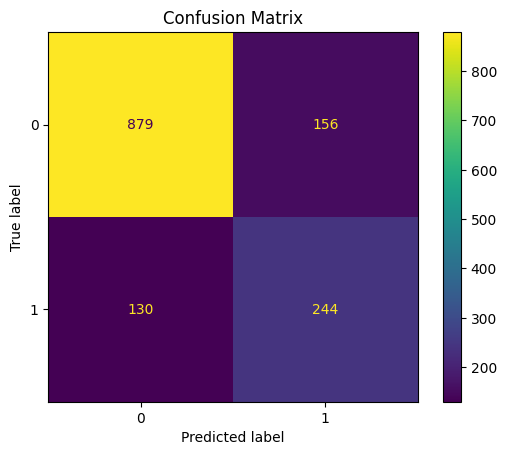

PR AUC Score: 0.661


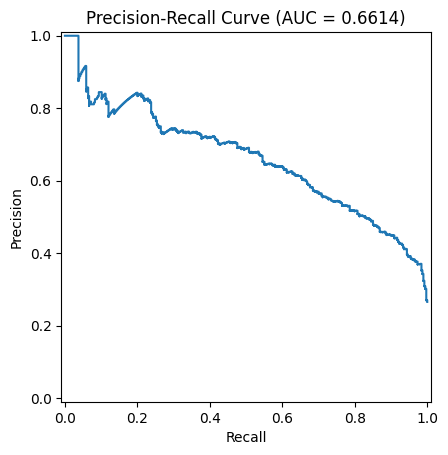

In [2408]:
model_eval.evaluate_model(y_test, y_pred, y_proba)